In [1]:
from google.colab import drive
drive.mount("/content/drive")

import glob
import pandas as pd

base = "/content/drive/MyDrive/ifood_marketing_analytics"
files = glob.glob(base + "/**/*.csv", recursive=True)
files

Mounted at /content/drive


['/content/drive/MyDrive/ifood_marketing_analytics/data/ifood_df.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_with_segments.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/segment_profile.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/target_list_top200.csv',
 '/content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_scored_all_customers.csv']

In [2]:
path = base + "/outputs/ifood_with_segments.csv"
df = pd.read_csv(path)

print("Loaded:", path)
print("Shape:", df.shape)
df.head()

Loaded: /content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_with_segments.csv
Shape: (2205, 45)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall,CustomerID,TotalKids,TotalPurchases,DealShare,Segment,SegmentName
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,1529,1441,0,1,0,25,0.120000,2,Quiet Value Regulars
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,21,15,0,2,2,6,0.333333,1,Deal Driven Browsers
2,71613.0,0,0,26,426,49,127,111,21,42,...,0,734,692,0,3,0,21,0.047619,2,Quiet Value Regulars
3,26646.0,1,0,26,11,4,20,10,3,5,...,0,48,43,0,4,1,8,0.250000,1,Deal Driven Browsers
4,58293.0,1,0,94,173,43,118,46,27,15,...,1,407,392,0,5,1,19,0.263158,2,Quiet Value Regulars


In [3]:
import numpy as np

target = "Response"

# Must-have core features
core = [
    "Income","Recency","MntTotal","TotalPurchases","DealShare",
    "NumWebVisitsMonth","TotalKids","AcceptedCmpOverall"
]

# Optional if present
optional = ["Age","Customer_Days"]

features = []
for c in core + optional:
    if c in df.columns:
        features.append(c)

# Add any one-hot encoded columns if they exist
for c in df.columns:
    if c.startswith("marital_") or c.startswith("education_"):
        features.append(c)

# Add segment if present (as numeric)
if "Segment" in df.columns:
    features.append("Segment")

print("Number of features:", len(features))
features

Number of features: 21


['Income',
 'Recency',
 'MntTotal',
 'TotalPurchases',
 'DealShare',
 'NumWebVisitsMonth',
 'TotalKids',
 'AcceptedCmpOverall',
 'Age',
 'Customer_Days',
 'marital_Divorced',
 'marital_Married',
 'marital_Single',
 'marital_Together',
 'marital_Widow',
 'education_2n Cycle',
 'education_Basic',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'Segment']

In [4]:
from sklearn.model_selection import train_test_split

X = df[features].copy()
y = df[target].copy()

# fill missing values
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1653, 21) (552, 21)


In [5]:
from sklearn.model_selection import train_test_split

X = df[features].copy()
y = df[target].copy()

# fill missing values
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1653, 21) (552, 21)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

pred_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, pred_lr)

print("Logistic Regression AUC:", round(auc_lr, 4))

Logistic Regression AUC: 0.8657


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    min_samples_leaf=5,
    n_jobs=-1
)
rf.fit(X_train, y_train)

pred_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, pred_rf)

print("Random Forest AUC:", round(auc_rf, 4))

Random Forest AUC: 0.8869


In [8]:
import pandas as pd
import numpy as np

eval_df = pd.DataFrame({
    "y_true": y_test.values,
    "pred": pred_rf
})

eval_df = eval_df.sort_values("pred", ascending=False).reset_index(drop=True)

top_n = int(0.10 * len(eval_df))
top_decile_rate = eval_df.head(top_n)["y_true"].mean()
overall_rate = eval_df["y_true"].mean()

lift = top_decile_rate / overall_rate if overall_rate > 0 else np.nan

print("Overall response rate:", round(overall_rate, 4))
print("Top 10 percent response rate:", round(top_decile_rate, 4))
print("Lift in top decile:", round(lift, 2))

Overall response rate: 0.1504
Top 10 percent response rate: 0.6545
Lift in top decile: 4.35


In [9]:
df = df.copy()
df["PredProb"] = rf.predict_proba(X)[:, 1]

# If SegmentName exists, include it. If not, create it from Segment numbers.
if "SegmentName" not in df.columns and "Segment" in df.columns:
    # placeholder
    df["SegmentName"] = df["Segment"].astype(str)

cols_out = ["CustomerID","PredProb","Income","Recency","MntTotal","TotalPurchases","DealShare","NumWebVisitsMonth"]
if "SegmentName" in df.columns:
    cols_out.insert(2, "SegmentName")

target_list = df[cols_out].sort_values("PredProb", ascending=False).head(200)
target_list.head(20)

,CustomerID,PredProb,SegmentName,Income,Recency,MntTotal,TotalPurchases,DealShare,NumWebVisitsMonth
800,801,0.856692,Premium Loyalists,76412.0,15,1791,18,0.055556,3
413,414,0.850790,Premium Loyalists,84865.0,1,1672,16,0.062500,4
320,321,0.843255,Premium Loyalists,75693.0,10,1412,22,0.045455,4
1545,1546,0.828007,Premium Loyalists,82800.0,23,1270,26,0.038462,3
14,15,0.828007,Premium Loyalists,82800.0,23,1270,26,0.038462,3
897,898,0.826010,Premium Loyalists,84169.0,9,1919,20,0.050000,3
526,527,0.826010,Premium Loyalists,84169.0,9,1919,20,0.050000,3
1819,1820,0.817306,Premium Loyalists,86836.0,7,494,23,0.043478,5
439,440,0.814215,Premium Loyalists,89572.0,44,1995,24,0.041667,4
1935,1936,0.803808,Premium Loyalists,71670.0,8,1606,15,0.066667,6


In [10]:
import os

out_base = base + "/outputs"
os.makedirs(out_base, exist_ok=True)

target_path = out_base + "/target_list_top200.csv"
df_scored_path = out_base + "/ifood_scored_all_customers.csv"

target_list.to_csv(target_path, index=False)
df.to_csv(df_scored_path, index=False)

print("Saved targeting list:", target_path)
print("Saved scored dataset:", df_scored_path)

Saved targeting list: /content/drive/MyDrive/ifood_marketing_analytics/outputs/target_list_top200.csv
Saved scored dataset: /content/drive/MyDrive/ifood_marketing_analytics/outputs/ifood_scored_all_customers.csv


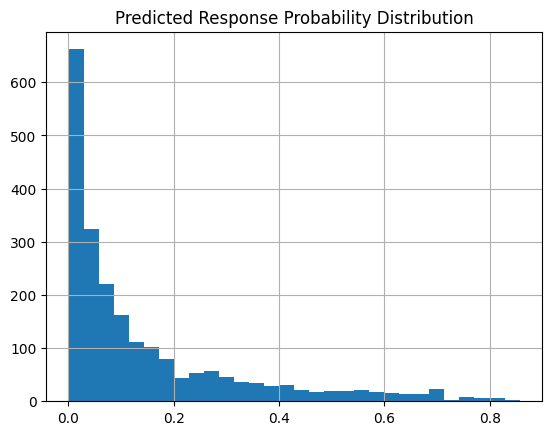

In [13]:
import matplotlib.pyplot as plt
import os

# Create the assets directory directly under the base folder
assets_dir = os.path.join(base, "assets")
os.makedirs(assets_dir, exist_ok=True)

plt.figure()
df["PredProb"].hist(bins=30)
plt.title("Predicted Response Probability Distribution")

# Save the figure
plt.savefig(os.path.join(assets_dir, "predicted_response_probability_distribution.png"))

plt.show()

	•	Random Forest outperformed baseline and achieved strong ranking power for campaign response.  ￼
	•	Top 10 percent predicted customers show a much higher response rate than overall, giving a lift of about 4.35.  ￼
	•	Next action: run campaign in waves, start with top 200 list, track response rate, and iterate weekly.
